# Import libraries

In [94]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scipy.signal import butter, filtfilt

# Load data

In [292]:
user_local_dir = "/home/maxence/dev/hardware/TMS/data_processing" # Change this to your local directory

components = ["x", "y", "z"]
components = ["MagVentureX", "MagVentureY", "MagVentureZ"]

trial_per_component = 2
capacitor_voltage = "1500"

# Data directory
rows = ["A", "B", "C", "D", "E", "F", "G", "H"]
data_folder_dir = os.path.join(user_local_dir, f"waveforms")
data_file_paths = [os.path.join(data_folder_dir, f"{component}_component/waveform_{r}{c}_{i}.csv") for component in components for r in rows for c in range(1, 16) for i in range(1, trial_per_component + 1)]
print(data_file_paths)
print(f"Data file paths: {data_file_paths}")

# Capacitor waveforms
#data_cap_file_paths = [os.path.join(data_folder_dir, f"capacitor_waveforms/waveform_{i}.csv") for i in range(1, len(os.listdir(os.path.join(data_folder_dir, "capacitor_waveforms"))) + 1)]
#print(f"Capacitor data file paths: {data_cap_file_paths}")

# Output directory
output_folder_dir = os.path.join(user_local_dir, "waveforms/plots")
os.makedirs(output_folder_dir, exist_ok=True)
print(f"Output folder directory: {output_folder_dir}")

['/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A1_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A1_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A2_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A2_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A3_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A3_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A4_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A4_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A5_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/MagVentureX_component/waveform_A5_2.csv',

In [293]:
data_csv = []
for data_file_dir in data_file_paths:
    try:
        df = pd.read_csv(data_file_dir)
        data_csv.append(df)
    except FileNotFoundError:
        # create empty DataFrame with the Voltage (V) column
        empty_df = pd.DataFrame(columns=["Voltage (V)"])
        data_csv.append(empty_df)
        
print(len(data_csv))
data_csv[0].head() 

720


,Voltage (V)


In [294]:
data_cap_csv = [pd.read_csv(data_cap_file_dir) for data_cap_file_dir in data_cap_file_paths]

NameError: name 'data_cap_file_paths' is not defined

# Plot capacitor waveform

In [ ]:
cap_waveforms = np.array([df["Voltage (V)"].values[5:] for df in data_cap_csv])
cap_waveform_mean = cap_waveforms.mean(axis=0)
cap_waveform_sd = cap_waveforms.std(axis=0)

print(cap_waveforms.max(axis=1), cap_waveforms.min(axis=1))

plt.plot(cap_waveform_mean, label="Mean Capacitor Waveform")
plt.fill_between(range(len(cap_waveform_mean)), cap_waveform_mean - cap_waveform_sd, cap_waveform_mean + cap_waveform_sd, alpha=0.2, label="SD of Capacitor Waveform")
plt.title("Mean Capacitor Waveform with SD")
plt.xlabel("Time (arbitrary units)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

NameError: name 'data_cap_csv' is not defined

# Clean data with low pass filtering

In [ ]:
def lowpass(signal, fs, fc, order=4):
    """Zero-phase Butterworth low-pass.
    fs : sample rate [Hz], fc : cutoff [Hz]"""
    nyq = 0.5 * fs
    b, a = butter(order, fc / nyq, btype="low")
    return filtfilt(b, a, signal)

In [ ]:
def sample_rate(t):
    dt = np.diff(np.asarray(t))
    return 1.0 / np.mean(dt)

In [295]:
data_csv_clean = []

fc = 0.1

for data_i in data_csv:
    if not data_i.empty:
        fs = sample_rate(data_i["Time (s)"][5:])
        data_i["Voltage (V)"] = lowpass(data_i["Voltage (V)"], fs, fc)  # Example cutoff frequency of 1000 Hz
        data_csv_clean.append(data_i[50:])
    else:
        data_csv_clean.append(data_i)

In [296]:
data_csv = data_csv_clean

# Plot Rx Voltage Map

[nan nan]
nan
9.674827232410696


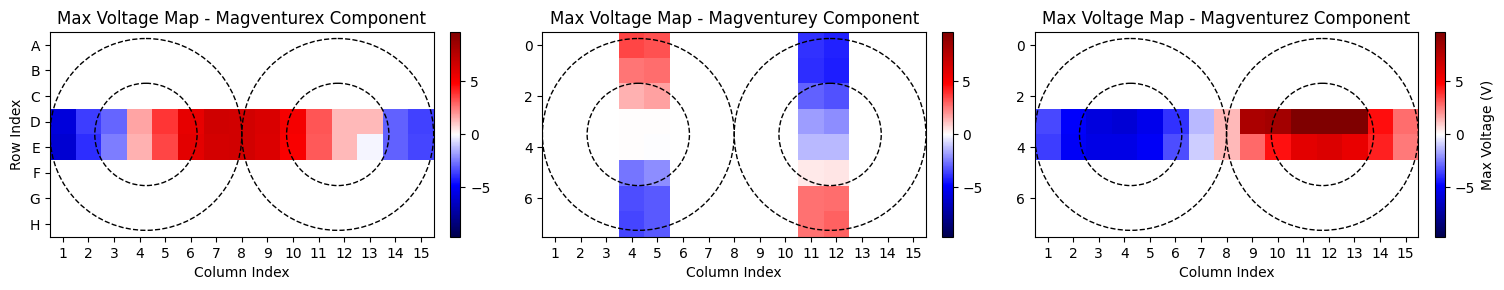

In [297]:
max_voltages = []
for i in range(len(data_csv)):
    if data_csv[i].empty:
        max_voltages.append(np.nan)
    else:
        v = data_csv[i]['Voltage (V)'].to_numpy()[5:]
        max_voltages.append(v[np.argmax(np.abs(v))])


max_voltages = np.array(max_voltages).reshape(3, 8, 15, trial_per_component)
print(max_voltages[0, 0, 13])
max_voltages_mean = max_voltages.mean(axis=3)
print(max_voltages_mean[0, 0, 13])

# Flip the voltages to compensate for coil orientation
max_voltages_mean[0] = max_voltages_mean[0]
max_voltages_mean[1] = -max_voltages_mean[1]
max_voltages_mean[2] = max_voltages_mean[2]

absolute_max = np.nanmax(np.abs(max_voltages_mean))
print(absolute_max)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

y_center = 3.5
x_left = 3.25
x_right = 10.75
r_out = 3.75
r_in = 2.0

for i, component in enumerate(components):
    axes[i].imshow(max_voltages_mean[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max)
    axes[i].set_title(f'Max Voltage Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(max_voltages_mean[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max), ax=axes[i], fraction=0.025, pad=0.04)

    axes[i].add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

    axes[i].add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))


cbar.set_label('Max Voltage (V)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

# Plot B-field Map

In [298]:
# We used a 1cm diameter self wounded coil.
area = np.pi * (0.01 / 2) ** 2 # in m^2
print(f"Area of Rx coil: {area} m^2")

N_turns = 10

NAeff = N_turns * area
print(f"N*A of Rx coil: {NAeff} m^2")

Area of Rx coil: 7.853981633974483e-05 m^2
N*A of Rx coil: 0.0007853981633974482 m^2


In [299]:
max_b_field = -max_voltages_mean / NAeff
dB_dt_emperical = max_b_field # save for later use in dI/dt estimation

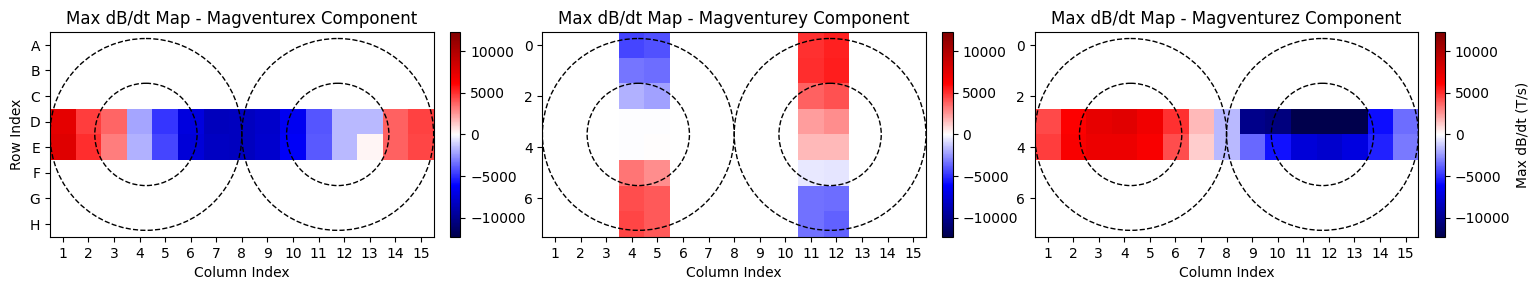

In [300]:

absolute_max_emp = np.nanmax(np.abs(max_b_field))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

y_center = 3.5
x_left = 3.25
x_right = 10.75
r_out = 3.75
r_in = 2.0

for i, component in enumerate(components):
    axes[i].imshow(max_b_field[i], cmap='seismic', vmin=-absolute_max_emp, vmax=absolute_max_emp)
    axes[i].set_title(f'Max dB/dt Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(max_b_field[i], cmap='seismic', vmin=-absolute_max_emp, vmax=absolute_max_emp), ax=axes[i], fraction=0.025, pad=0.04)

    axes[i].add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

    axes[i].add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

cbar.set_label('Max dB/dt (T/s)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

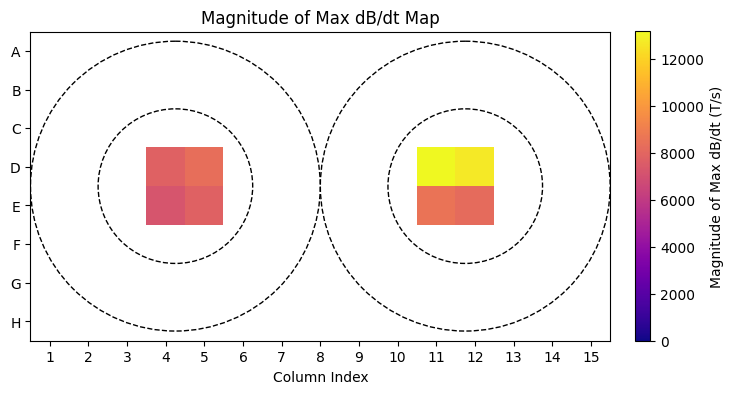

In [301]:
# plot magnitude of dB/dt
max_b_field_magnitude = np.linalg.norm(max_b_field, axis=0)
absolute_max = np.nanmax(max_b_field_magnitude)

plt.figure(figsize=(8, 6))
plt.imshow(max_b_field_magnitude, cmap='plasma', vmin=0, vmax=absolute_max)
plt.title('Magnitude of Max dB/dt Map')
plt.xlabel('Column Index')
plt.xticks(ticks=np.arange(15), labels=np.arange(1, 16))
plt.yticks(ticks=np.arange(len(rows)), labels=rows)
cbar = plt.colorbar(fraction=0.025, pad=0.04)
cbar.set_label('Magnitude of Max dB/dt (T/s)')

ax = plt.gca()

ax.add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
ax.add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

ax.add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
ax.add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

plt.show()

# Plot E-field Map

In [302]:
import numpy as np

def generate_tms_coil_segments(n_turns=5, r_in=0.02, r_out=0.0375, layer_gap=0.003, wing_offset=0.038, n_pts_per_loop=72):
    """
    Generates 3D wire segments for a 20-loop stacked figure-8 TMS coil.
    """
    radii = np.linspace(r_in, r_out, n_turns)
    segments_start = []
    segments_end = []
    
    # Layers: z = 0 (bottom), z = layer_gap (top)
    layers = [0.0, layer_gap]
    
    # Wings: left (negative x), right (positive x)
    wings = [('left', -1), ('right', 1)]
    
    for z in layers:
        for side, x_sign in wings:
            center_x = x_sign * wing_offset
            
            # Left wing is counter-clockwise (1), Right wing is clockwise (-1)
            direction = 1 if side == 'left' else -1
            
            for r in radii:
                # Generate angles for the circle
                theta = np.linspace(0, 2 * np.pi, n_pts_per_loop)
                if direction == -1:
                    theta = theta[::-1]
                    
                x = center_x + r * np.cos(theta)
                y = r * np.sin(theta)
                
                # Create start and end points for each straight segment
                for i in range(len(theta) - 1):
                    p1 = [x[i], y[i], z]
                    p2 = [x[i+1], y[i+1], z]
                    segments_start.append(p1)
                    segments_end.append(p2)
                    
    return np.array(segments_start), np.array(segments_end)


def generate_mri_b91_segments(n_turns=4, 
                              r_in_x=0.0175, r_in_y=0.026, 
                              r_out_x=0.0395, r_out_y=0.046, 
                              layer_gap=0.005, wing_offset=0.0395, 
                              n_pts_per_loop=72):
    """
    Generates 3D wire segments for the 2-layer, elliptical MagVenture MRI-B91 coil.
    Vertices are generated in a local coil coordinate frame.
    """
    # Interpolate radii independently for the elliptical spirals
    radii_x = np.linspace(r_in_x, r_out_x, n_turns)
    radii_y = np.linspace(r_in_y, r_out_y, n_turns)
    
    segments_start = []
    segments_end = []
    
    # 2 layers for B91
    layers = [0.0, layer_gap]
    
    # Wings: left (negative x), right (positive x)
    wings = [('left', -1), ('right', 1)]
    
    for z in layers:
        for side, x_sign in wings:
            center_x = x_sign * wing_offset
            
            # Left wing is counter-clockwise (1), Right wing is clockwise (-1)
            direction = 1 if side == 'left' else -1
            
            for rx, ry in zip(radii_x, radii_y):
                # Generate angles for the ellipse
                theta = np.linspace(0, 2 * np.pi, n_pts_per_loop)
                if direction == -1:
                    theta = theta[::-1]
                    
                x = center_x + rx * np.cos(theta)
                y = ry * np.sin(theta)
                
                # Create start and end points for each straight segment
                for i in range(len(theta) - 1):
                    p1 = [x[i], y[i], z]
                    p2 = [x[i+1], y[i+1], z]
                    segments_start.append(p1)
                    segments_end.append(p2)
                    
    return np.array(segments_start), np.array(segments_end)


# Generate the mesh
starts, ends = generate_tms_coil_segments()
print(f"Total wire segments generated: {len(starts)}")


# Generate the B91 mesh
starts, ends = generate_mri_b91_segments()
print(f"Total wire segments generated for MRI-B91: {len(starts)}")

Total wire segments generated: 1420
Total wire segments generated for MRI-B91: 1136


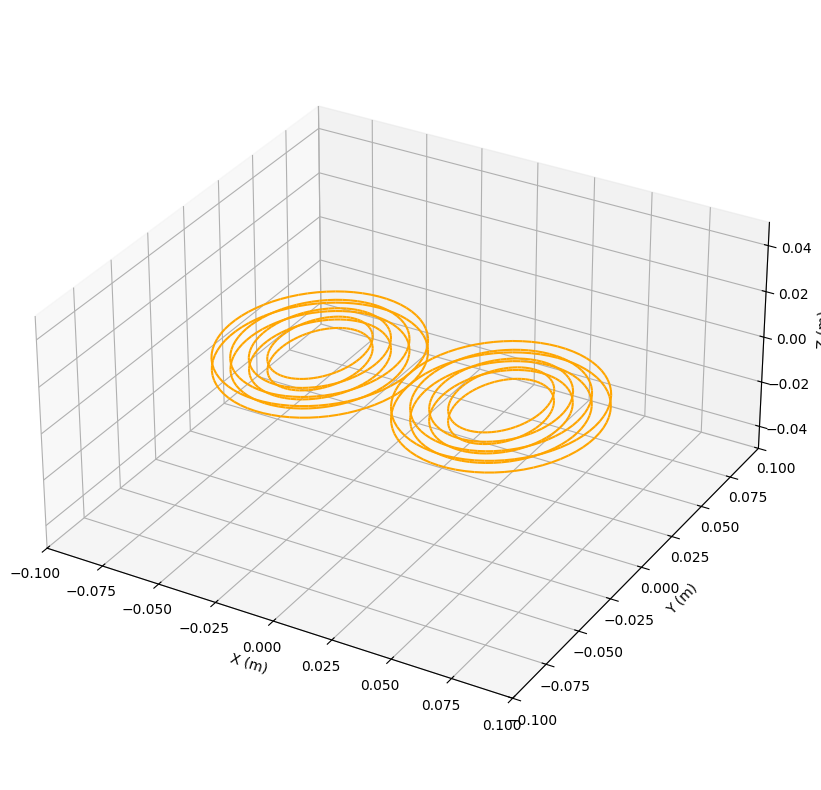

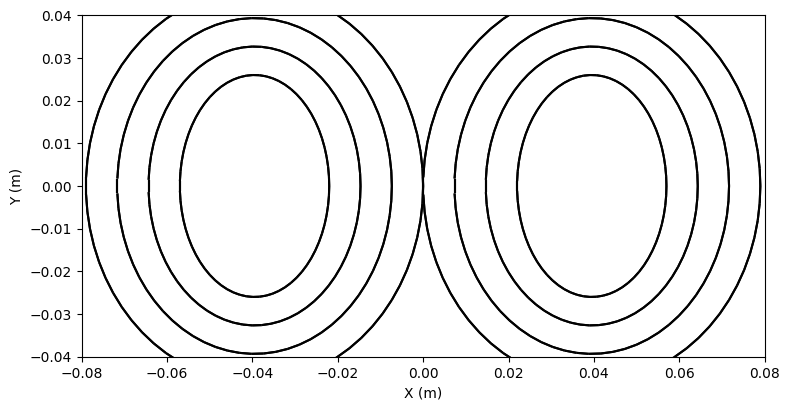

In [303]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.collections import LineCollection
import numpy as np

def visualize_coil_3d(starts, ends):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Pair start and end coordinates for each segment
    segments = [(start, end) for start, end in zip(starts, ends)]
    
    # Add segments to the 3D plot
    lc = Line3DCollection(segments, colors='orange', linewidths=1.5)
    ax.add_collection3d(lc)
    
    # Define spatial boundaries to center the coil
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.1, 0.1)
    ax.set_zlim(-0.05, 0.05)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    
    # Force the aspect ratio to maintain physical proportions
    ax.set_box_aspect([1, 1, 0.5])
    
    plt.tight_layout()
    plt.show()


def visualize_coil_2d(starts, ends):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Pair start and end coordinates for each segment
    segments = [(start[:2], end[:2]) for start, end in zip(starts, ends)]
    
    # Add segments to the 2D plot
    lc = LineCollection(segments, colors='black', linewidths=1.5)
    ax.add_collection(lc)
    
    # Define spatial boundaries to center the coil
    ax.set_xlim(-0.08, 0.08)
    ax.set_ylim(-0.04, 0.04)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

# Execute visualization using previously generated arrays
visualize_coil_3d(starts, ends)

visualize_coil_2d(starts, ends)

In [354]:

def compute_dB_dt(starts, ends, target_points, dI_dt=1.0):
    """
    Computes the time derivative of the magnetic field (dB/dt)
    at target points for a given dI/dt using discrete wire segments.
    """
    mu_0 = 4 * np.pi * 1e-7
    
    # Calculate segment vectors and midpoints
    dl = ends - starts
    midpoints = (starts + ends) / 2.0
    
    # Initialize output array
    dB_dt = np.zeros_like(target_points, dtype=float)
    
    # Iterate over target points
    for i, point in enumerate(target_points):
        # Calculate distance vectors from segment midpoints to the target point
        r_vec = point - midpoints
        r_mag = np.linalg.norm(r_vec, axis=1)[:, np.newaxis]
        
        # Prevent division by zero
        r_mag[r_mag == 0] = 1e-10 
        
        # Calculate cross product dl x r_vec
        cross_prod = np.cross(dl, r_vec)
        
        # Calculate dB/dt contribution from each segment
        integrand = cross_prod / (r_mag**3)
        dB_dt[i] = (mu_0 / (4 * np.pi)) * dI_dt * np.sum(integrand, axis=0)
        
    return dB_dt

# Generate 15x8 cm grid with 1 cm spacing
x_vals = np.linspace(-0.075, 0.075, 15) # go from left to right
y_vals = np.linspace(0.04, -0.04, 8) # go from top to bottom (y decreases as we go down)
grid_x, grid_y = np.meshgrid(x_vals, y_vals)

# Position grid 1.5 cm below the coil (z = -0.015)
grid_z = np.full_like(grid_x, -0.0205) # NOT COIL-TO-COIL

# Flatten grid into a list of [x, y, z] coordinates
target_pts = np.column_stack((grid_x.ravel(), grid_y.ravel(), grid_z.ravel()))

# Compute field. #115.65 MA/s calculated at 1470V
di_dt_initial_guess = 115e6 # 1.5 MA/s for TMS pulse
dB_dt_values = compute_dB_dt(starts, ends, target_pts, dI_dt=di_dt_initial_guess)

# Extract components
dBx_dt, dBy_dt, dBz_dt = dB_dt_values.reshape(grid_x.shape[0], grid_x.shape[1], 3).transpose(2, 0, 1)
dB_dt_mag = np.linalg.norm(dB_dt_values, axis=1).reshape(grid_x.shape)

dB_dt_model = np.stack((dBx_dt, dBy_dt, dBz_dt), axis=0)

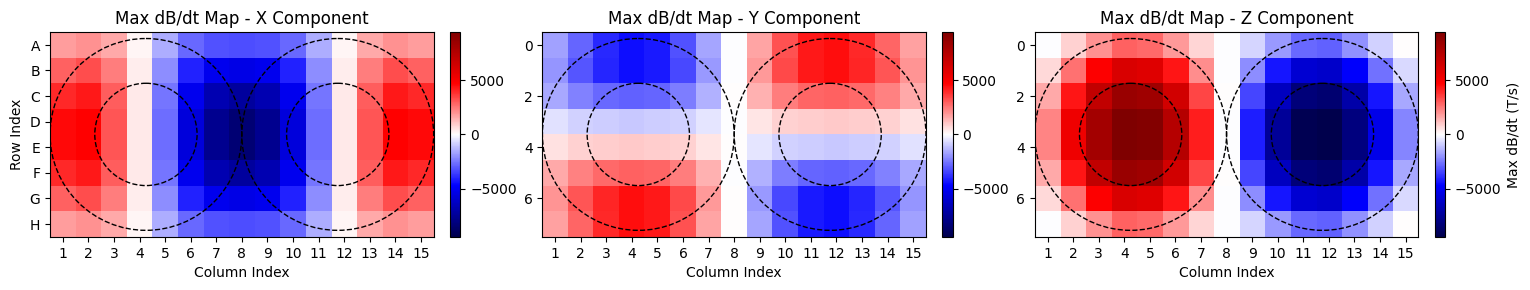

In [348]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

absolute_max_model = np.max(np.abs(dB_dt_model))

y_center = 3.5
x_left = 3.25
x_right = 10.75
r_out = 3.75
r_in = 2.0

components = ['x', 'y', 'z']
for i, component in enumerate(components):
    axes[i].imshow(dB_dt_model[i], cmap='seismic', vmin=-absolute_max_model, vmax=absolute_max_model, origin="upper")
    axes[i].set_title(f'Max dB/dt Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(dB_dt_model[i], cmap='seismic', vmin=-absolute_max_model, vmax=absolute_max_model), ax=axes[i], fraction=0.025, pad=0.04)

    axes[i].add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

    axes[i].add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
    axes[i].add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

cbar.set_label('Max dB/dt (T/s)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

## Empirical vs Model Comparison

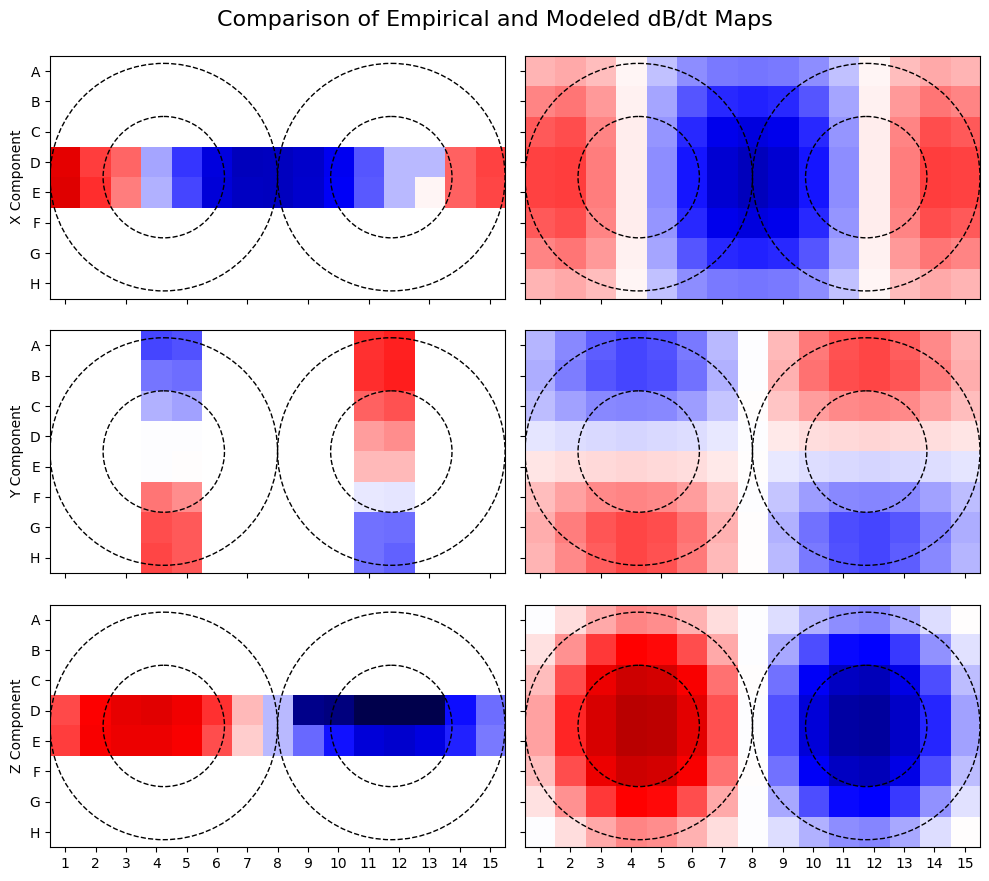

In [349]:

fig, axes = plt.subplots(3, 2, figsize=(10, 9))

absolute_max = np.max([absolute_max_emp, absolute_max_model])

y_center = 3.5
x_left = 3.25
x_right = 10.75
r_out = 3.75
r_in = 2.0

components = ['x', 'y', 'z']
for i, data in enumerate([max_b_field, dB_dt_model]):
    for j, component in enumerate(components):
        axes[j, i].imshow(data[j], cmap='seismic', vmin=-absolute_max, vmax=absolute_max, origin="upper")

        axes[j, i].set_xticklabels([])
        axes[j, i].set_yticklabels([])

        if j == 2:
            axes[j, i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    

        if i == 0:
            axes[j, i].set_yticks(ticks=np.arange(len(rows)), labels=rows)
            axes[j, i].set_yticklabels(["A", "B", "C", "D", "E", "F", "G", "H"])

            axes[j, i].set_ylabel(f'{component.capitalize()} Component')

        #if i == 1 and j == 2:
        #    # add colorbar
        #    cbar = plt.colorbar(axes[j, i].imshow(data[j], cmap='seismic', vmin=-absolute_max, vmax=absolute_max), ax=axes[j, i], fraction=0.025, pad=0.04)

        axes[j, i].add_patch(Circle((x_left, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
        axes[j, i].add_patch(Circle((x_left, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

        axes[j, i].add_patch(Circle((x_right, y_center), r_out, fill=False, color='black', linewidth=1, linestyle='--'))
        axes[j, i].add_patch(Circle((x_right, y_center), r_in, fill=False, color='black', linewidth=1, linestyle='--'))

cbar.set_label('Max dB/dt (T/s)')

#axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
#axes[0].set_ylabel('Row Index')

plt.suptitle('Comparison of Empirical and Modeled dB/dt Maps', fontsize=16)

plt.tight_layout()
plt.show()

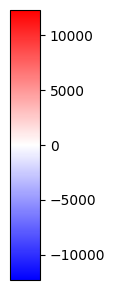

In [350]:
# Create colorbar for the last plot
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
fig = plt.figure(figsize=(0.5, 3))
norm = Normalize(vmin=-absolute_max, vmax=absolute_max)
mappable = ScalarMappable(norm=norm, cmap='bwr')
mappable.set_array([])
cax = fig.add_axes([0.15, 0.05, 0.6, 0.9])
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')
#cbar.set_label('Max dB/dt (T/s)')
plt.show()


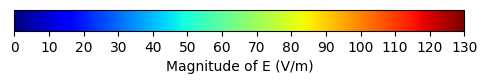

In [351]:
# Create horizontal colorbar for the last plot
fig = plt.figure(figsize=(5, 0.3))
norm = Normalize(vmin=0, vmax=130)
# Make sure extremums are displayed in the colorbar ticks
mappable = ScalarMappable(norm=norm, cmap='jet')
mappable.set_array([])
cax = fig.add_axes([0.05, 0.15, 0.9, 0.7])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_ticks(np.arange(0, 131, 10))
cbar.set_label('Magnitude of E (V/m)')
plt.show()

In [352]:

def calculate_current_derivative(emp_dB_dt, mod_dB_dt):
    """
    Calculates the true dI/dt scalar using a linear least-squares fit.
    
    Parameters:
    emp_dB_dt : numpy array of measured dB/dt values (N_points, 3).
    mod_dB_dt : numpy array of modeled dB/dt values (N_points, 3).
    """
    
    # Flatten the arrays to 1D vectors for a global least-squares fit
    emp_vector = emp_dB_dt.ravel()
    mod_vector = mod_dB_dt.ravel()

    # Keep only valid (non-NaN) entries
    valid_mask = ~np.isnan(emp_vector) & ~np.isnan(mod_vector)
    emp_vector = emp_vector[valid_mask]
    mod_vector = mod_vector[valid_mask]
    
    # Compute the dot products
    numerator = np.dot(emp_vector, mod_vector)
    denominator = np.dot(mod_vector, mod_vector)
    
    # Check for zero division
    if denominator == 0:
        return 0.0
        
    # Calculate the optimal scalar
    dI_dt = numerator / denominator
    
    return dI_dt


k = calculate_current_derivative(dB_dt_emperical, dB_dt_model)
dI_dt_val = k * di_dt_initial_guess
print(f"Estimated dI/dt: {dI_dt_val*1e-6:.2f} MA/s")

Estimated dI/dt: 113.48 MA/s


R^2 of linear fit: 0.8923


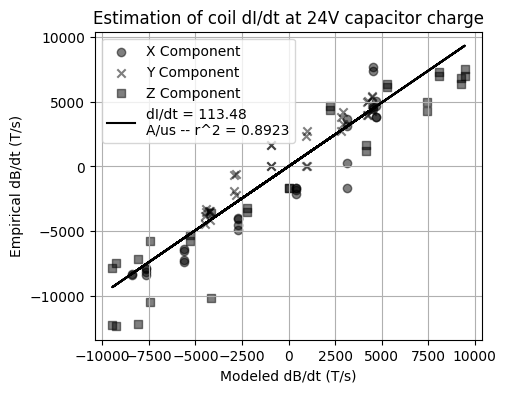

In [353]:
# Plot linear correlation between empirical and modeled dB/dt values
emp_vector = dB_dt_emperical.ravel()
mod_vector = dB_dt_model.ravel()

# Keep only valid (non-NaN) entries
valid_mask = ~np.isnan(emp_vector) & ~np.isnan(mod_vector)
emp_vector = emp_vector[valid_mask]
mod_vector = mod_vector[valid_mask]

r2 = np.corrcoef(emp_vector, mod_vector)[0, 1] ** 2
print(f"R^2 of linear fit: {r2:.4f}")

plt.figure(figsize=(5, 4))
#plt.scatter(mod_vector, emp_vector, color="blue", alpha=0.5)
plt.scatter(mod_vector[0:30], emp_vector[0:30], color="black", marker="o", alpha=0.5, label="X Component")
plt.scatter(mod_vector[30:62], emp_vector[30:62], color="k", marker="x", alpha=0.5, label="Y Component")
plt.scatter(mod_vector[62:92], emp_vector[62:92], color="k", marker="s", alpha=0.5, label="Z Component")
plt.plot(mod_vector, k * mod_vector, color='black', label=f'dI/dt = {dI_dt_val*1e-6:.2f}\nA/us -- r^2 = {r2:.4f}')
plt.xlabel('Modeled dB/dt (T/s)')
plt.ylabel('Empirical dB/dt (T/s)')
plt.title('Estimation of coil dI/dt at 24V capacitor charge')
plt.legend()
plt.grid()
plt.show()


In [325]:
def compute_total_e_field(starts, ends, dI_dt, sphere_radius=0.085, gap=0.01):
    """
    Computes peak E-field on a spherical conductor surface.
    """
    mu_0 = 4 * np.pi * 1e-7
    sphere_center = np.array([0, 0, -(sphere_radius + gap)])
    
    # Generate grid on the top "cap" of the sphere
    theta = np.linspace(-np.pi/4, np.pi/4, 50)
    phi = np.linspace(-np.pi/4, np.pi/4, 50)
    THETA, PHI = np.meshgrid(theta, phi)
    
    # Spherical to Cartesian relative to sphere center
    X = sphere_radius * np.sin(THETA) * np.cos(PHI)
    Y = sphere_radius * np.sin(PHI)
    Z_rel = sphere_radius * np.cos(THETA) * np.cos(PHI)
    
    target_pts = np.column_stack((X.ravel(), Y.ravel(), (Z_rel + sphere_center[2]).ravel()))
    
    # 1. Compute dA/dt (Vector Potential Derivative)
    dl = ends - starts
    midpoints = (starts + ends) / 2.0
    dA_dt = np.zeros_like(target_pts)
    
    for i, point in enumerate(target_pts):
        r_vec = point - midpoints
        r_mag = np.linalg.norm(r_vec, axis=1)[:, np.newaxis]
        dA_dt[i] = (mu_0 / (4 * np.pi)) * dI_dt * np.sum(dl / r_mag, axis=0)
    
    # 2. Total E-field Calculation
    E_primary = -dA_dt
    
    # Define unit radial vectors from sphere center to target points
    r_vectors = target_pts - sphere_center
    r_hats = r_vectors / np.linalg.norm(r_vectors, axis=1)[:, np.newaxis]
    
    # Calculate radial component: (E_primary dot r_hat) * r_hat
    dot_product = np.sum(E_primary * r_hats, axis=1)[:, np.newaxis]
    E_radial = dot_product * r_hats
    
    # E_total is tangential component
    E_total = E_primary - E_radial
    E_mag = np.linalg.norm(E_total, axis=1).reshape(THETA.shape)
    
    return X, Y, E_mag

# Usage
X_surf, Y_surf, E_vals = compute_total_e_field(starts, ends, dI_dt_val)
print(f"Peak Electric Field: {np.max(E_vals):.2f} V/m")

Peak Electric Field: 311.22 V/m


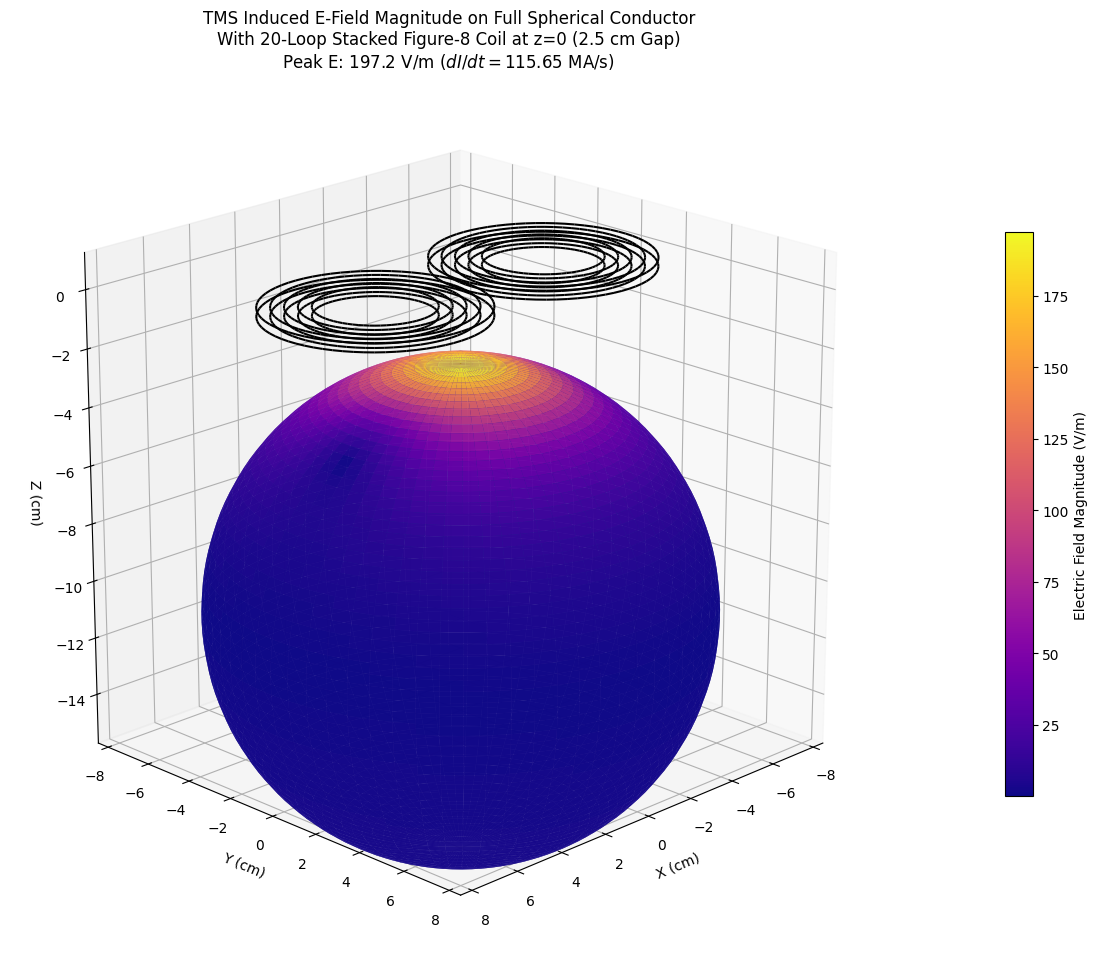

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# --- 1. Coil Geometry Generation (Discrete Wire Segments) ---
def generate_tms_coil_segments(n_turns=5, r_in=0.02, r_out=0.0375, layer_gap=0.003, wing_offset=0.038, n_pts_per_loop=72):
    """Generates 3D wire segments for a 20-loop stacked figure-8 TMS coil."""
    radii = np.linspace(r_in, r_out, n_turns)
    segments_start = []
    segments_end = []
    layers = [0.0, layer_gap] # z-coordinates of layers
    wings = [('left', -1), ('right', 1)] # wing centers along x-axis
    
    for z in layers:
        for side, x_sign in wings:
            center_x = x_sign * wing_offset
            # Left wing counter-clockwise (1), Right wing clockwise (-1)
            direction = 1 if side == 'left' else -1
            
            for r in radii:
                theta_loop = np.linspace(0, 2 * np.pi, n_pts_per_loop)
                if direction == -1:
                    theta_loop = theta_loop[::-1]
                x = center_x + r * np.cos(theta_loop)
                y = r * np.sin(theta_loop)
                
                # Create segments
                for i in range(len(theta_loop) - 1):
                    p1 = [x[i], y[i], z]
                    p2 = [x[i+1], y[i+1], z]
                    segments_start.append(p1)
                    segments_end.append(p2)
                    
    return np.array(segments_start), np.array(segments_end)

# --- 2. Electric Field Calculation (Vectorized over segments) ---
def compute_total_e_field_vectorized(starts, ends, dI_dt, target_pts, sphere_center):
    """
    Computes induced tangential E-field on a spherical conductor surface.
    target_pts shape: (M_points, 3)
    """
    mu_0 = 4 * np.pi * 1e-7
    
    # Coil segments data
    dl = ends - starts  # (N_segments, 3)
    midpoints = (starts + ends) / 2.0 # (N_segments, 3)
    
    # dA_dt initialization
    dA_dt = np.zeros_like(target_pts)
    
    # Biot-Savart vector potential calculation (vectorized over segments)
    for i, point in enumerate(target_pts):
        r_vec = point - midpoints # (N_segments, 3)
        r_mag = np.linalg.norm(r_vec, axis=1)[:, np.newaxis] # (N_segments, 1)
        r_mag[r_mag == 0] = 1e-10  # Prevent singularity
        
        # primary contribution: dl / |r|
        dA_dt[i] = (mu_0 / (4 * np.pi)) * dI_dt * np.sum(dl / r_mag, axis=0)
    
    # Total E-field Calculation (primary + secondary)
    # The secondary electrostatic field for a homogeneous sphere 
    # cancels the radial component of the primary inductive field (-dA/dt).
    E_primary = -dA_dt
    
    # Enforce boundary condition (remove radial component relative to sphere center)
    r_vectors = target_pts - sphere_center
    r_norms = np.linalg.norm(r_vectors, axis=1)[:, np.newaxis]
    r_norms[r_norms == 0] = 1.0 # Safety
    r_hats = r_vectors / r_norms
    
    # Dot product calculation: component parallel to radius
    dot_product = np.sum(E_primary * r_hats, axis=1)[:, np.newaxis]
    E_radial = dot_product * r_hats
    
    # Total tangential E-field
    E_total = E_primary - E_radial
    E_mag = np.linalg.norm(E_total, axis=1)
    
    return E_mag

# --- 3. Parameters and Geometry Setup ---
sphere_radius_val = 0.085 # 8.5 cm (cortical surface)
gap_val = 0.025 # 1 cm gap (scalp/hair)
# Sphere centered such that its top (z=-0.01) is 1cm below coil origin (z=0)
sphere_center_val = np.array([0, 0, -(sphere_radius_val + gap_val)])

# Generate Coil mesh
starts_val, ends_val = generate_tms_coil_segments()
coil_segments = [(start, end) for start, end in zip(starts_val, ends_val)]

# Define grid for FULL sphere
n_phi, n_theta = 72, 72 # Full sphere resolution
phi_sphere = np.linspace(0, 2 * np.pi, n_phi)  # Azimuth
theta_sphere = np.linspace(0, np.pi, n_theta) # Polar angle
PHI_S, THETA_S = np.meshgrid(phi_sphere, theta_sphere)

# Spherical to Cartesian relative to sphere center
X_rel_s = sphere_radius_val * np.sin(THETA_S) * np.cos(PHI_S)
Y_rel_s = sphere_radius_val * np.sin(THETA_S) * np.sin(PHI_S)
Z_rel_s = sphere_radius_val * np.cos(THETA_S)

# Absolute Cartesian coordinates of sphere surface
X_abs_s = X_rel_s
Y_abs_s = Y_rel_s
Z_abs_s = Z_rel_s + sphere_center_val[2]

# --- 4. Main Execution (Calculate and Visualize) ---
# Flatten surface coordinates for vectorized E-field calculation
target_pts_s = np.column_stack((X_abs_s.ravel(), Y_abs_s.ravel(), Z_abs_s.ravel()))

# Compute E-field magnitude on full sphere surface
E_mag_s_vals = compute_total_e_field_vectorized(starts_val, ends_val, dI_dt_val, target_pts_s, sphere_center_val)
E_mag_s = E_mag_s_vals.reshape(X_abs_s.shape)
peak_E_s = np.max(E_mag_s_vals)

# Visualization Setup
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# -- Plot 1: The Full Sphere with E-Field Hotspot --
# Normalize E-mag for color mapping on the surface
E_min = 0 # force minimum to 0 for contrast
E_norm_s = (E_mag_s - E_min) / (peak_E_s - E_min)

# Plot the sphere surface, mapping facecolors to E_mag using 'plasma'
surf_s = ax.plot_surface(X_abs_s * 100, Y_abs_s * 100, Z_abs_s * 100, 
                         facecolors=cm.plasma(E_norm_s),
                         rstride=1, cstride=1, 
                         antialiased=True, linewidth=0, shade=False, alpha=0.9)

# -- Plot 2: The TMS Coil --
# Add wire segments using Line3DCollection
coil_color = "black"
# Line3DCollection expects segments in cm for consistency with axis scaling
coil_segments_cm = [ (np.array(s)*100, np.array(e)*100) for s,e in coil_segments ]
lc_coil = Line3DCollection(coil_segments_cm, colors=coil_color, linewidths=1.5)
ax.add_collection3d(lc_coil)

# -- Formatting and Context --
ax.set_title(f'TMS Induced E-Field Magnitude on Full Spherical Conductor\nWith 20-Loop Stacked Figure-8 Coil at z=0 ({gap_val*100:.1f} cm Gap)\nPeak E: {peak_E_s:.1f} V/m ($dI/dt= {dI_dt_val*1e-6:.2f}$ MA/s)')
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_zlabel('Z (cm)')

# Set isometric view aspect ratio (equal scaling on all axes)
limits_cm = np.array([X_abs_s.min(), X_abs_s.max(), Y_abs_s.min(), Y_abs_s.max(), Z_abs_s.min(), 0.05]) * 100
max_range = limits_cm[1] - limits_cm[0]
mid_x = (limits_cm[0]+limits_cm[1])/2
mid_y = (limits_cm[2]+limits_cm[3])/2
mid_z = (limits_cm[4]+limits_cm[5])/2
ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
ax.set_zlim(mid_z - max_range/2, mid_z + max_range/2)
ax.set_box_aspect([1,1,1]) # modern matplotlib method

# Colorbar for Electric Field Magnitude
m = cm.ScalarMappable(cmap=cm.plasma)
m.set_array(E_mag_s)
cbar = fig.colorbar(m, ax=ax, shrink=0.6, aspect=20, label='Electric Field Magnitude (V/m)', orientation='vertical', pad=0.1)

# Set initial viewpoint
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()